# 📊 Exploratory Data Analysis — Criteo Uplift Dataset

Notebook này thực hiện EDA trên bộ dữ liệu **Criteo Uplift** đã được xử lý, sử dụng các hàm tiện ích từ module `src.data.eda`.

**Nội dung chính:**
1. Tổng quan dataset (shape, missing values, duplicate rows)
2. Phân phối Treatment & Target
3. Conversion Rate theo nhóm Treatment / Control
4. Thống kê mô tả các features
5. Phân tích Skewness
6. Correlation Heatmap
7. Histogram phân phối từng feature

## 0 · Setup

In [3]:
import sys
from pathlib import Path

# Đảm bảo import được module src từ project root
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from src.data.eda import (
    dataset_overview,
    treatment_distribution,
    target_distribution,
    conversion_by_treatment,
    feature_summary,
    feature_skewness,
    get_target_column,
)
from src.data.constants import FEATURE_COLS, TREATMENT_COL

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("Setup OK ✅")

Setup OK ✅


## 1 · Load dữ liệu

In [4]:
TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train.parquet"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file tại {TRAIN_PATH}.\n"
        "Hãy chạy `python -m src.data.make_dataset` trước."
    )

df = pd.read_parquet(TRAIN_PATH)
target_col = get_target_column(df)

print(f"Shape       : {df.shape}")
print(f"Target col  : {target_col}")
df.head()

Shape       : (700000, 13)
Target col  : conversion


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,treatment,conversion
0,23.020863,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,1,0
1,26.362804,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,1,0
2,22.754534,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,1,0
3,22.155815,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,1,0
4,24.914278,10.059654,8.214383,4.679882,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,1,0


## 2 · Tổng quan Dataset

In [5]:
overview = dataset_overview(df, target_col)
overview.T.rename(columns={0: "value"})

,value
n_rows,700000
n_columns,13
target_col,conversion
treatment_rate,1.0
target_rate,0.004756
missing_values,0
duplicate_rows,13750


In [6]:
# Kiểm tra kiểu dữ liệu
df.dtypes.to_frame("dtype")

,dtype
f0,float64
f1,float64
f2,float64
f3,float64
f4,float64
f5,float64
f6,float64
f7,float64
f8,float64
f9,float64


In [7]:
# Missing values theo cột
missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Không có missing values 🎉")
else:
    display(missing.to_frame("missing_count"))

Không có missing values 🎉


## 3 · Phân phối Treatment

,group,treatment,n_users,share
0,treatment,1,700000,1.0


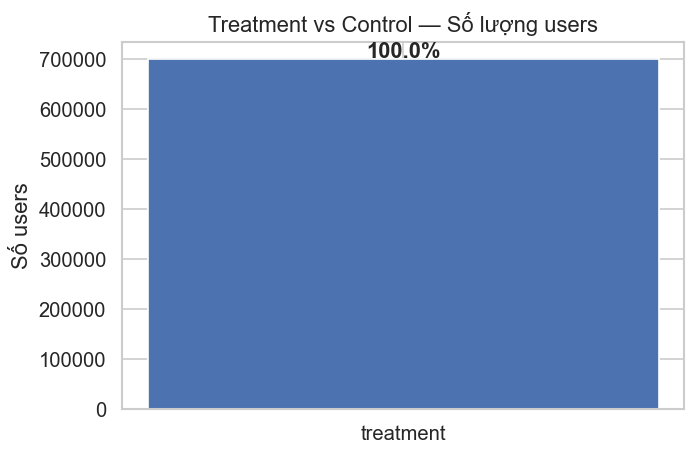

In [8]:
treat_dist = treatment_distribution(df)
display(treat_dist)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4C72B0", "#DD8452"]
ax.bar(treat_dist["group"], treat_dist["n_users"], color=colors, edgecolor="white")
for i, row in treat_dist.iterrows():
    ax.text(i, row["n_users"] + len(df)*0.005,
            f"{row['share']:.1%}", ha="center", fontweight="bold")
ax.set_title("Treatment vs Control — Số lượng users")
ax.set_ylabel("Số users")
plt.tight_layout()
plt.show()

## 4 · Phân phối Target

,conversion,n_users,share
0,0,696671,0.995244
1,1,3329,0.004756


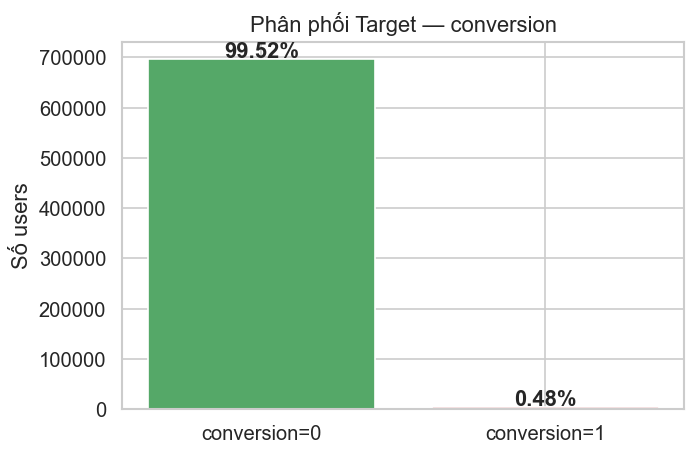

In [9]:
target_dist = target_distribution(df, target_col)
display(target_dist)

fig, ax = plt.subplots(figsize=(6, 4))
labels = [f"{target_col}={v}" for v in target_dist[target_col]]
colors = ["#55A868", "#C44E52"]
ax.bar(labels, target_dist["n_users"], color=colors, edgecolor="white")
for i, row in target_dist.iterrows():
    ax.text(i, row["n_users"] + len(df)*0.005,
            f"{row['share']:.2%}", ha="center", fontweight="bold")
ax.set_title(f"Phân phối Target — {target_col}")
ax.set_ylabel("Số users")
plt.tight_layout()
plt.show()

## 5 · Conversion Rate theo Treatment Group

,group,treatment,n_users,conversion_rate
0,treatment,1,700000,0.004756
1,difference,None,None,NaN


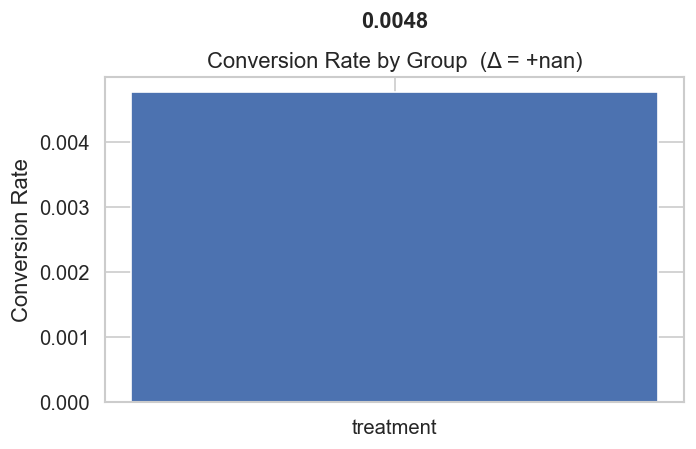

In [10]:
conv_report = conversion_by_treatment(df, target_col)
display(conv_report)

# Chỉ vẽ control vs treatment (bỏ dòng difference)
plot_data = conv_report[conv_report["group"].isin(["control", "treatment"])].copy()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(plot_data["group"], plot_data["conversion_rate"],
              color=colors, edgecolor="white")
for bar, rate in zip(bars, plot_data["conversion_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{rate:.4f}", ha="center", fontweight="bold")

diff_row = conv_report[conv_report["group"] == "difference"]
if not diff_row.empty:
    diff_val = diff_row["conversion_rate"].iloc[0]
    ax.set_title(f"Conversion Rate by Group  (Δ = {diff_val:+.4f})")
else:
    ax.set_title("Conversion Rate by Group")

ax.set_ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

## 6 · Thống kê mô tả các Features

In [11]:
feat_summary = feature_summary(df)
feat_summary.style.format(precision=4)

,feature,count,mean,std,min,25%,50%,75%,max
0,f0,700000.0000,21.6211,4.5892,12.6164,20.7746,22.9678,24.6727,26.7452
1,f1,700000.0000,10.0675,0.0965,10.0597,10.0597,10.0597,10.0597,15.0405
2,f2,700000.0000,8.3440,0.2546,8.2144,8.2144,8.2144,8.2245,9.0520
3,f3,700000.0000,4.3519,1.1219,-6.3990,4.6799,4.6799,4.6799,4.6799
4,f4,700000.0000,10.3625,0.4561,10.2805,10.2805,10.2805,10.2805,20.0361
5,f5,700000.0000,4.0339,0.4151,-7.7815,4.1155,4.1155,4.1155,4.1155
6,f6,700000.0000,-4.4772,4.1360,-27.1214,-6.6993,-3.2821,-1.2882,0.2944
7,f7,700000.0000,5.1000,1.2055,4.8338,4.8338,4.8338,4.8338,11.9983
8,f8,700000.0000,3.9528,0.0426,3.6351,3.9554,3.9719,3.9719,3.9719
9,f9,700000.0000,14.4306,4.6899,13.1901,13.1901,13.1901,13.1901,66.4904


## 7 · Phân tích Skewness

,feature,skewness,abs_skewness
1,f1,17.4466,17.4466
5,f5,-7.5451,7.5451
4,f4,7.4892,7.4892
10,f10,5.1940,5.1940
9,f9,4.6543,4.6543
7,f7,4.5105,4.5105
3,f3,-4.2048,4.2048
8,f8,-2.6937,2.6937
2,f2,1.7009,1.7009
6,f6,-1.1535,1.1535


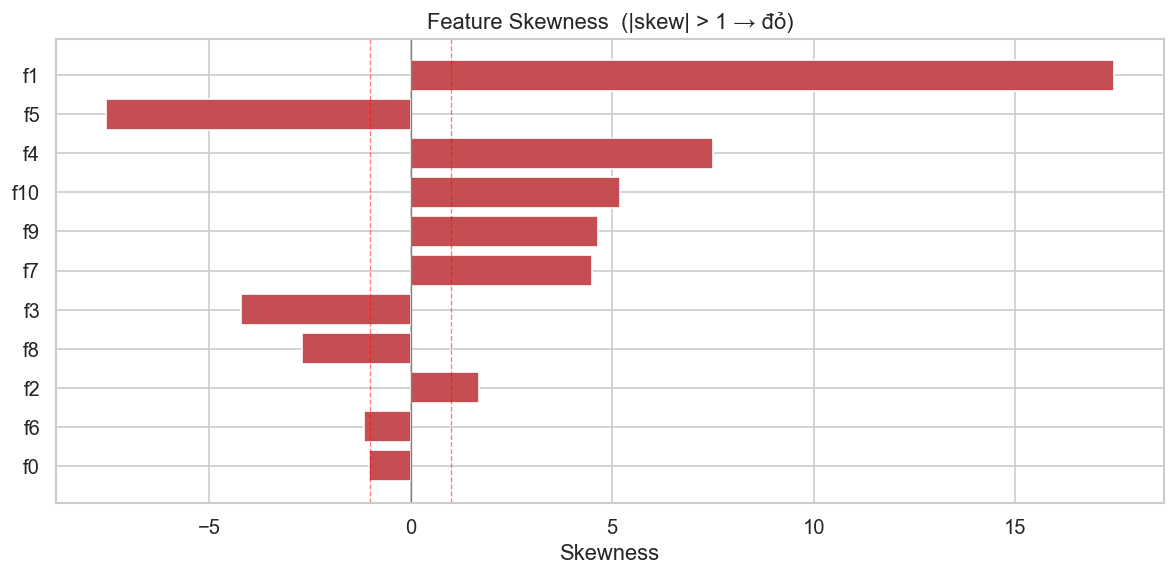

In [12]:
skew_report = feature_skewness(df)
display(skew_report.style.format(precision=4))

fig, ax = plt.subplots(figsize=(10, 5))
palette = ["#C44E52" if abs(s) > 1 else "#4C72B0" for s in skew_report["skewness"]]
ax.barh(skew_report["feature"], skew_report["skewness"], color=palette, edgecolor="white")
ax.axvline(0, color="grey", linewidth=0.8)
ax.axvline(-1, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(1, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Skewness")
ax.set_title("Feature Skewness  (|skew| > 1 → đỏ)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8 · Correlation Heatmap

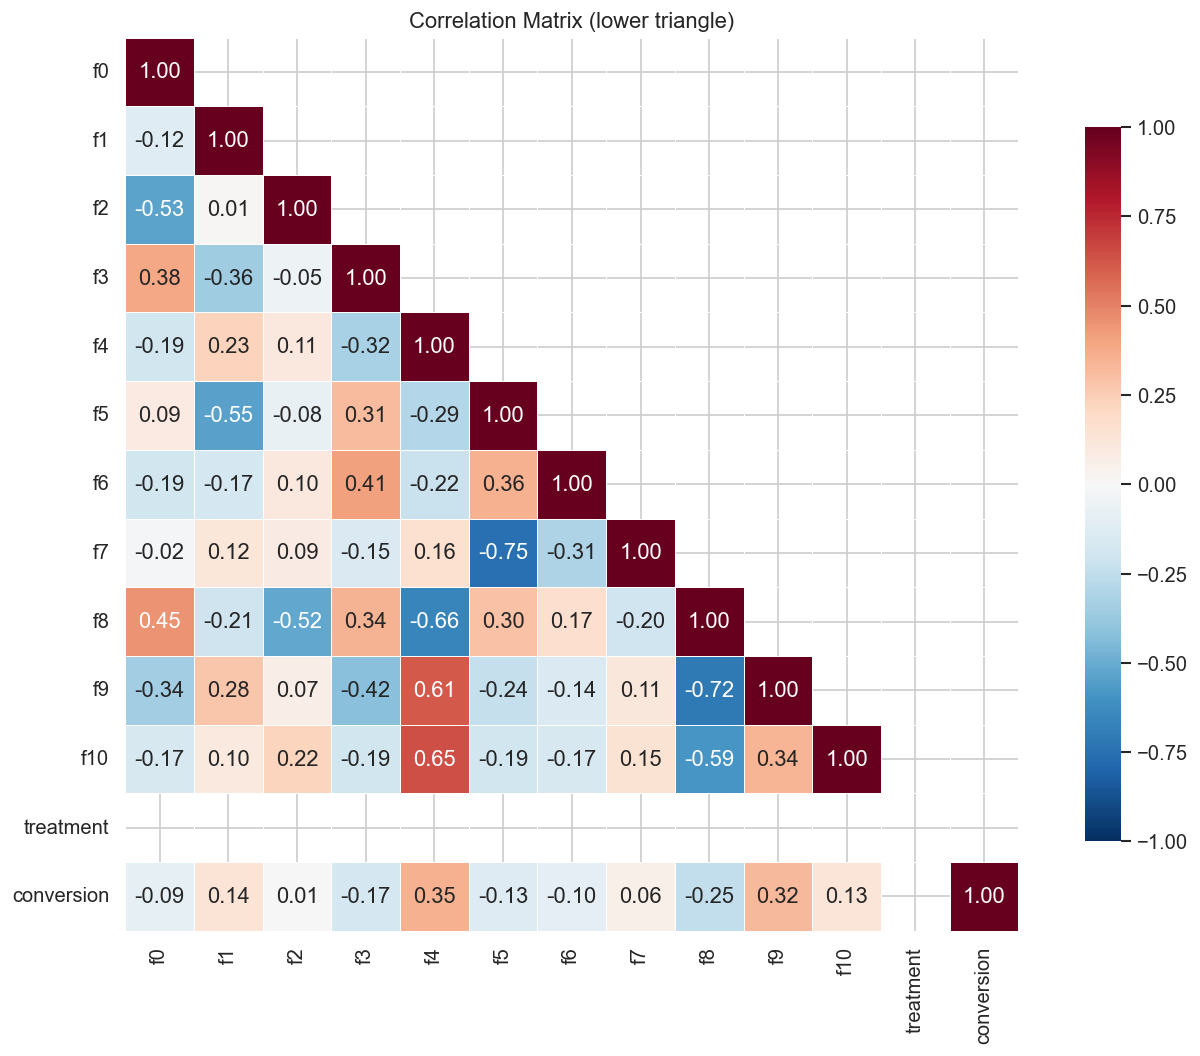

In [13]:
corr = df[FEATURE_COLS + [TREATMENT_COL, target_col]].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.show()

## 9 · Histogram phân phối từng Feature

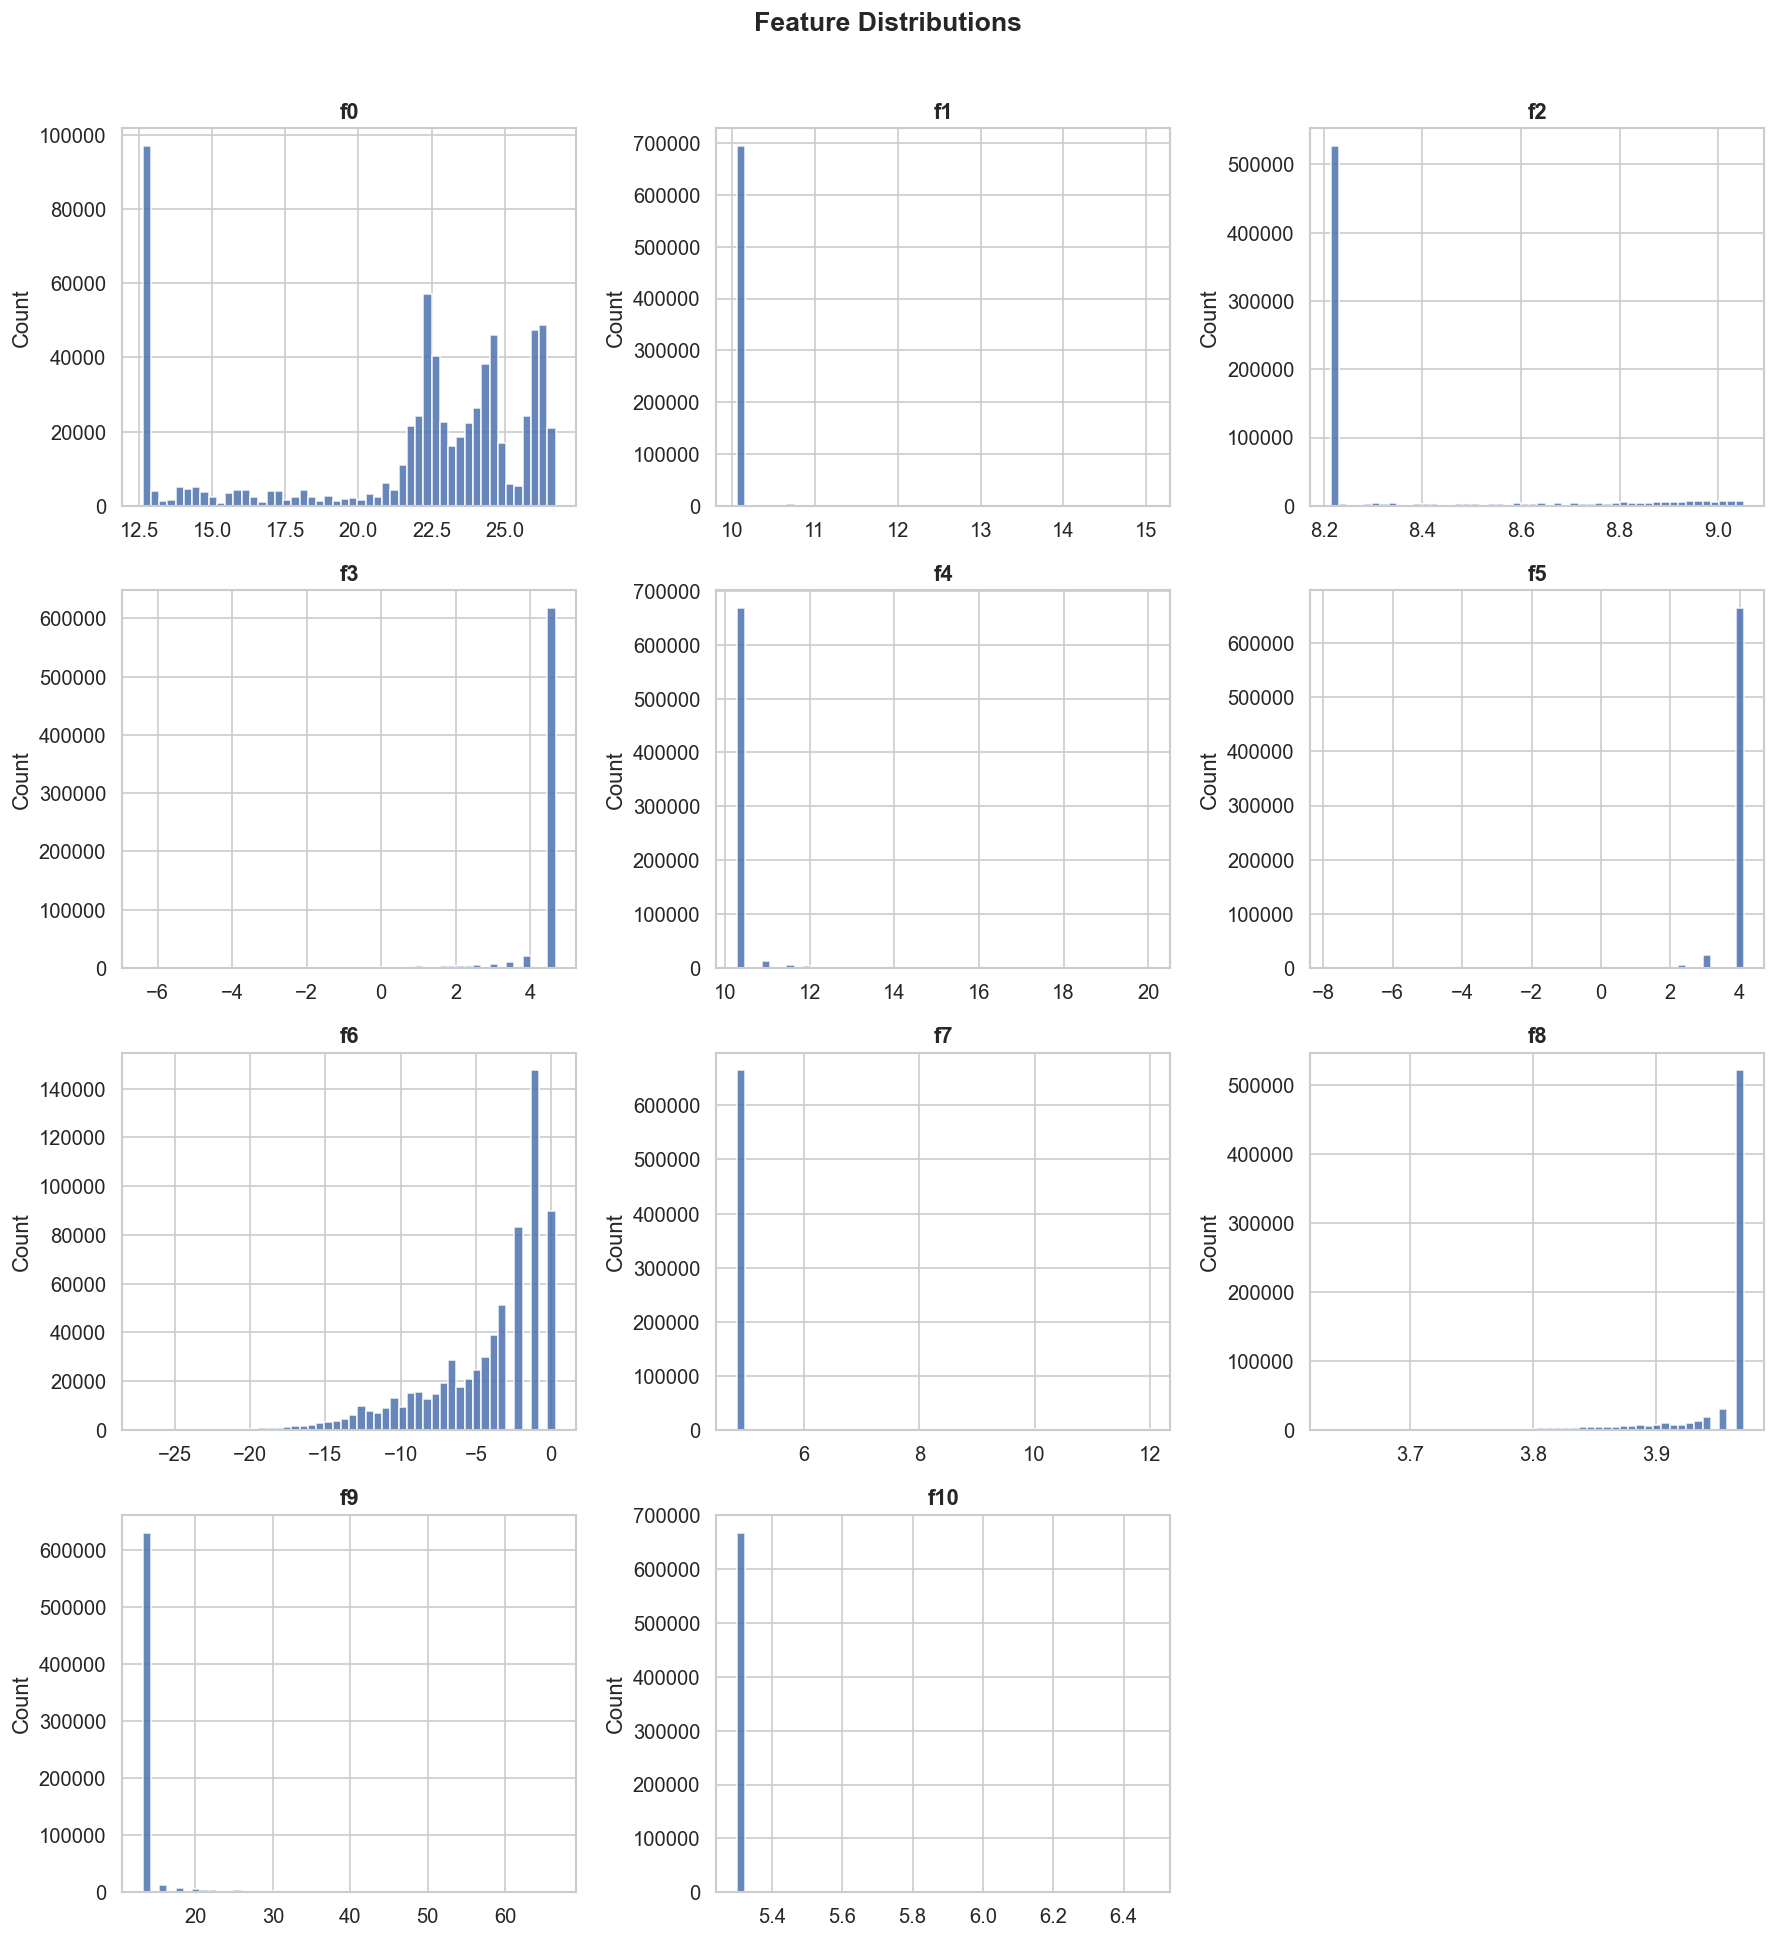

In [14]:
n_features = len(FEATURE_COLS)
ncols = 3
nrows = (n_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    ax.hist(df[feat].dropna(), bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

# Ẩn subplot thừa
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 10 · Feature Distribution theo Treatment Group

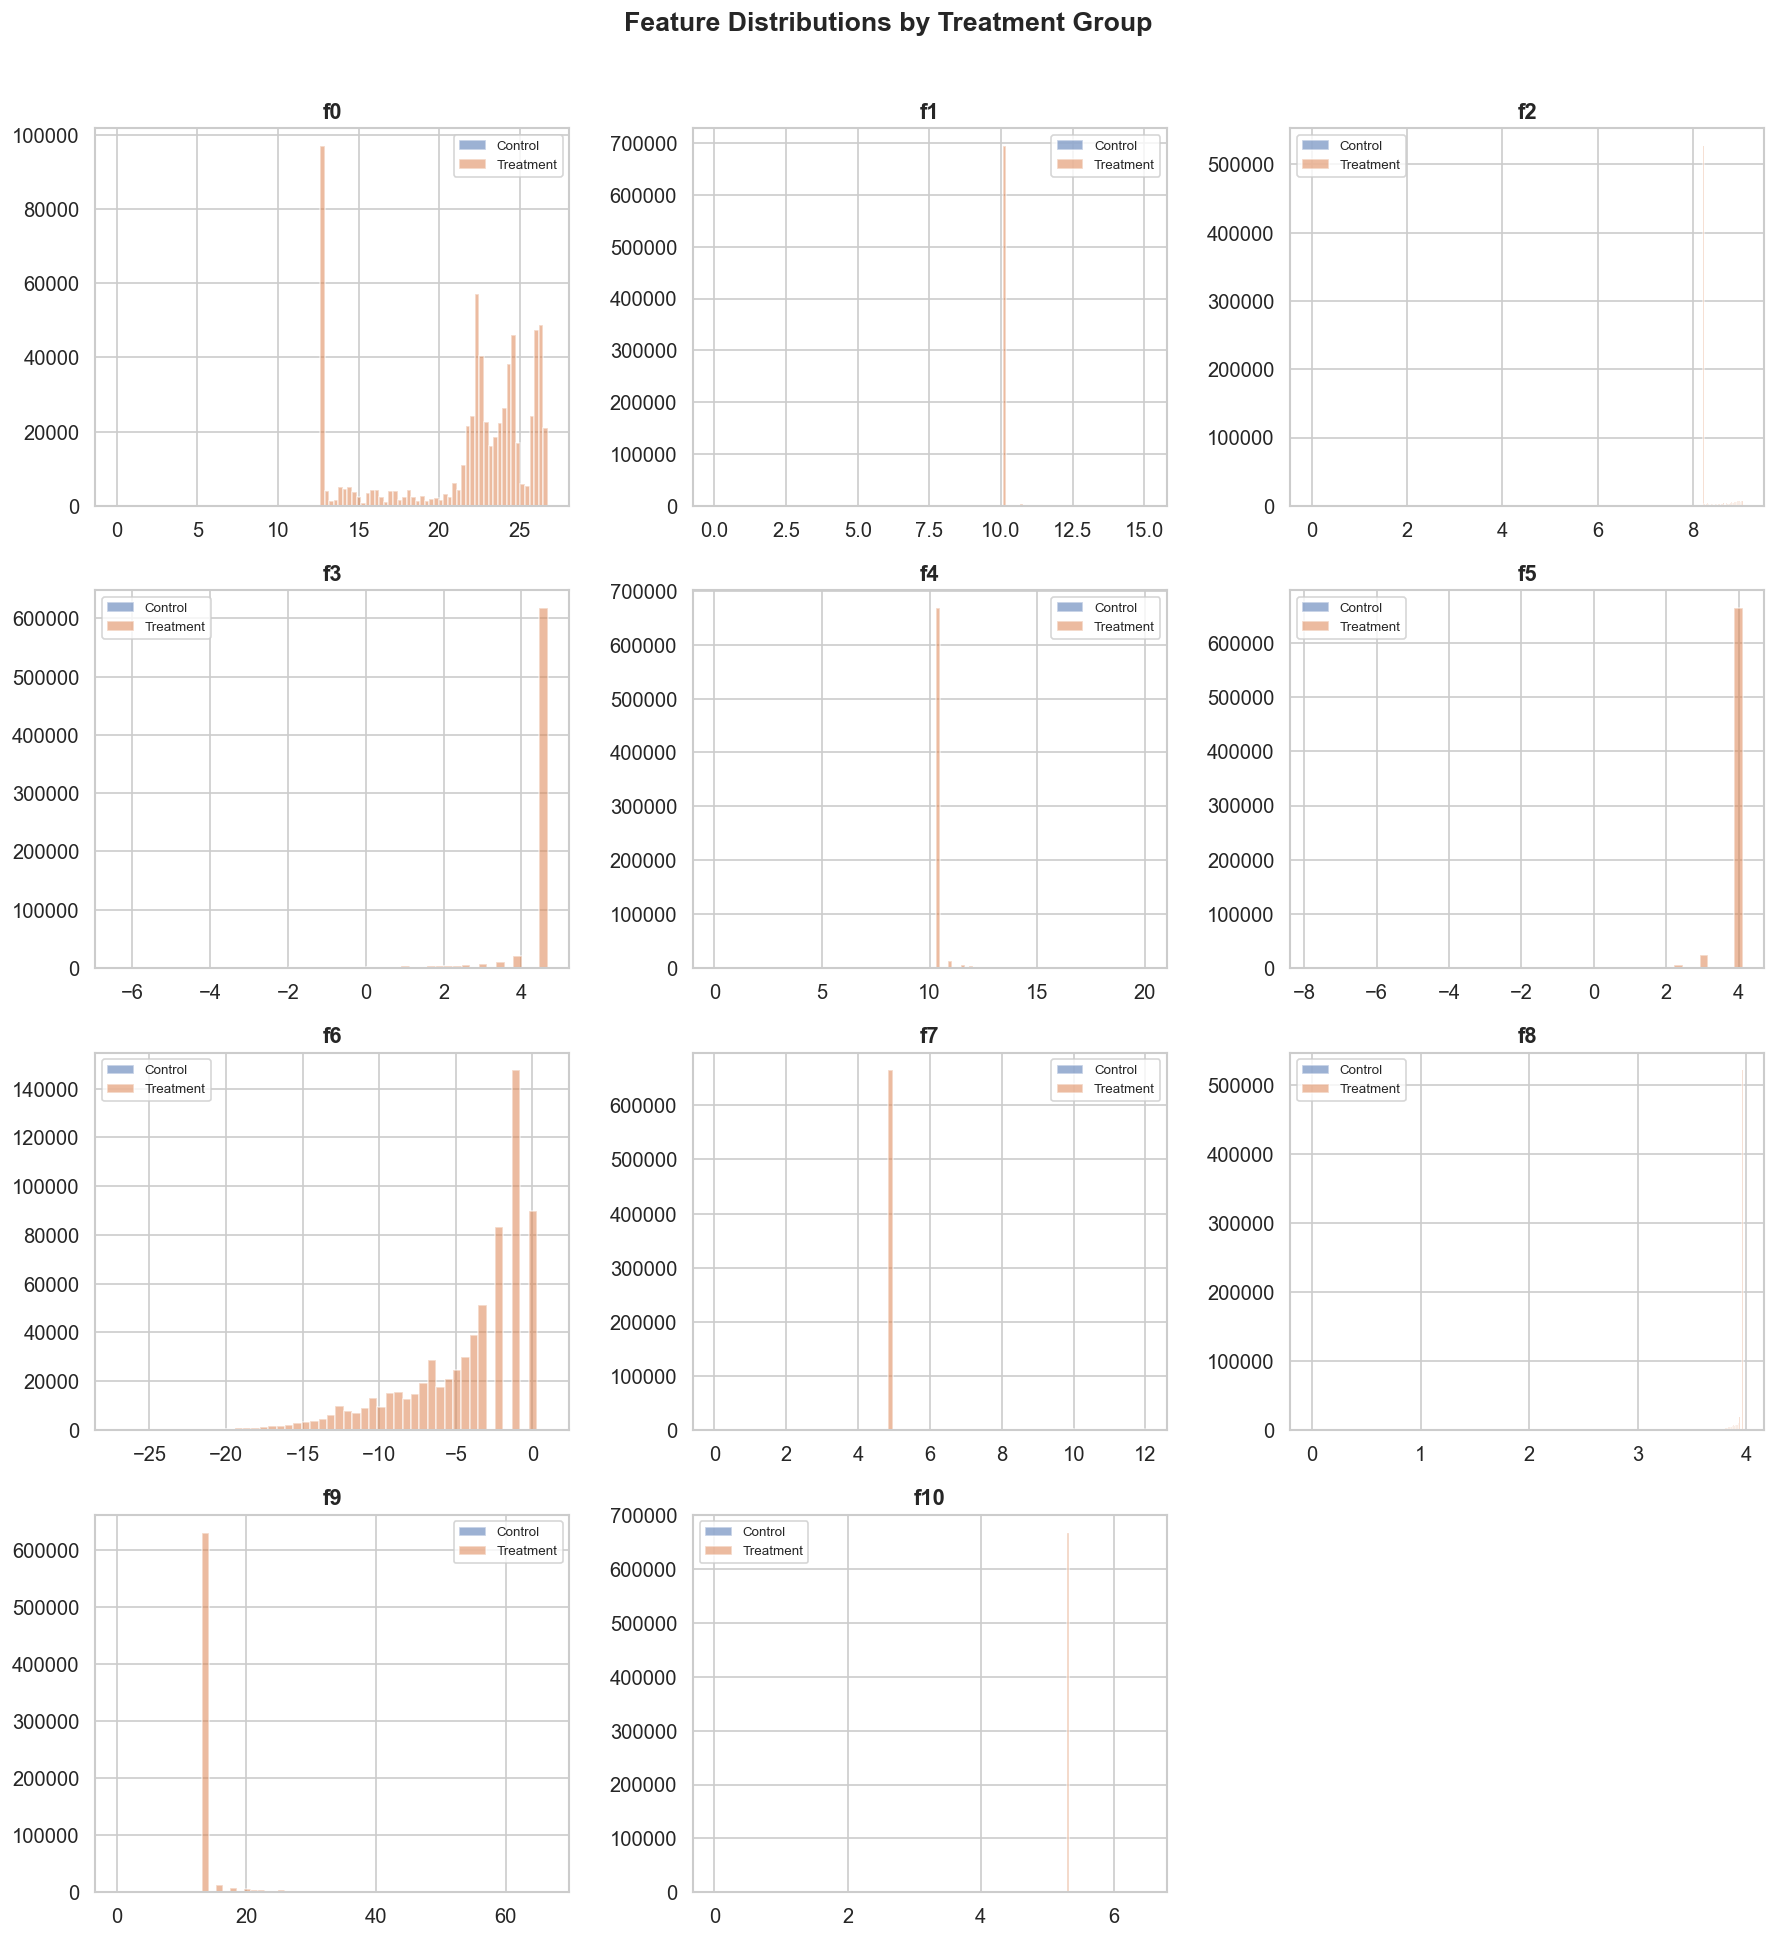

In [15]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for grp, color, label in [(0, "#4C72B0", "Control"), (1, "#DD8452", "Treatment")]:
        subset = df.loc[df[TREATMENT_COL] == grp, feat].dropna()
        ax.hist(subset, bins=50, alpha=0.55, color=color, label=label, edgecolor="white")
    ax.set_title(feat, fontweight="bold")
    ax.legend(fontsize=8)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature Distributions by Treatment Group", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 11 · Box‑plot Features

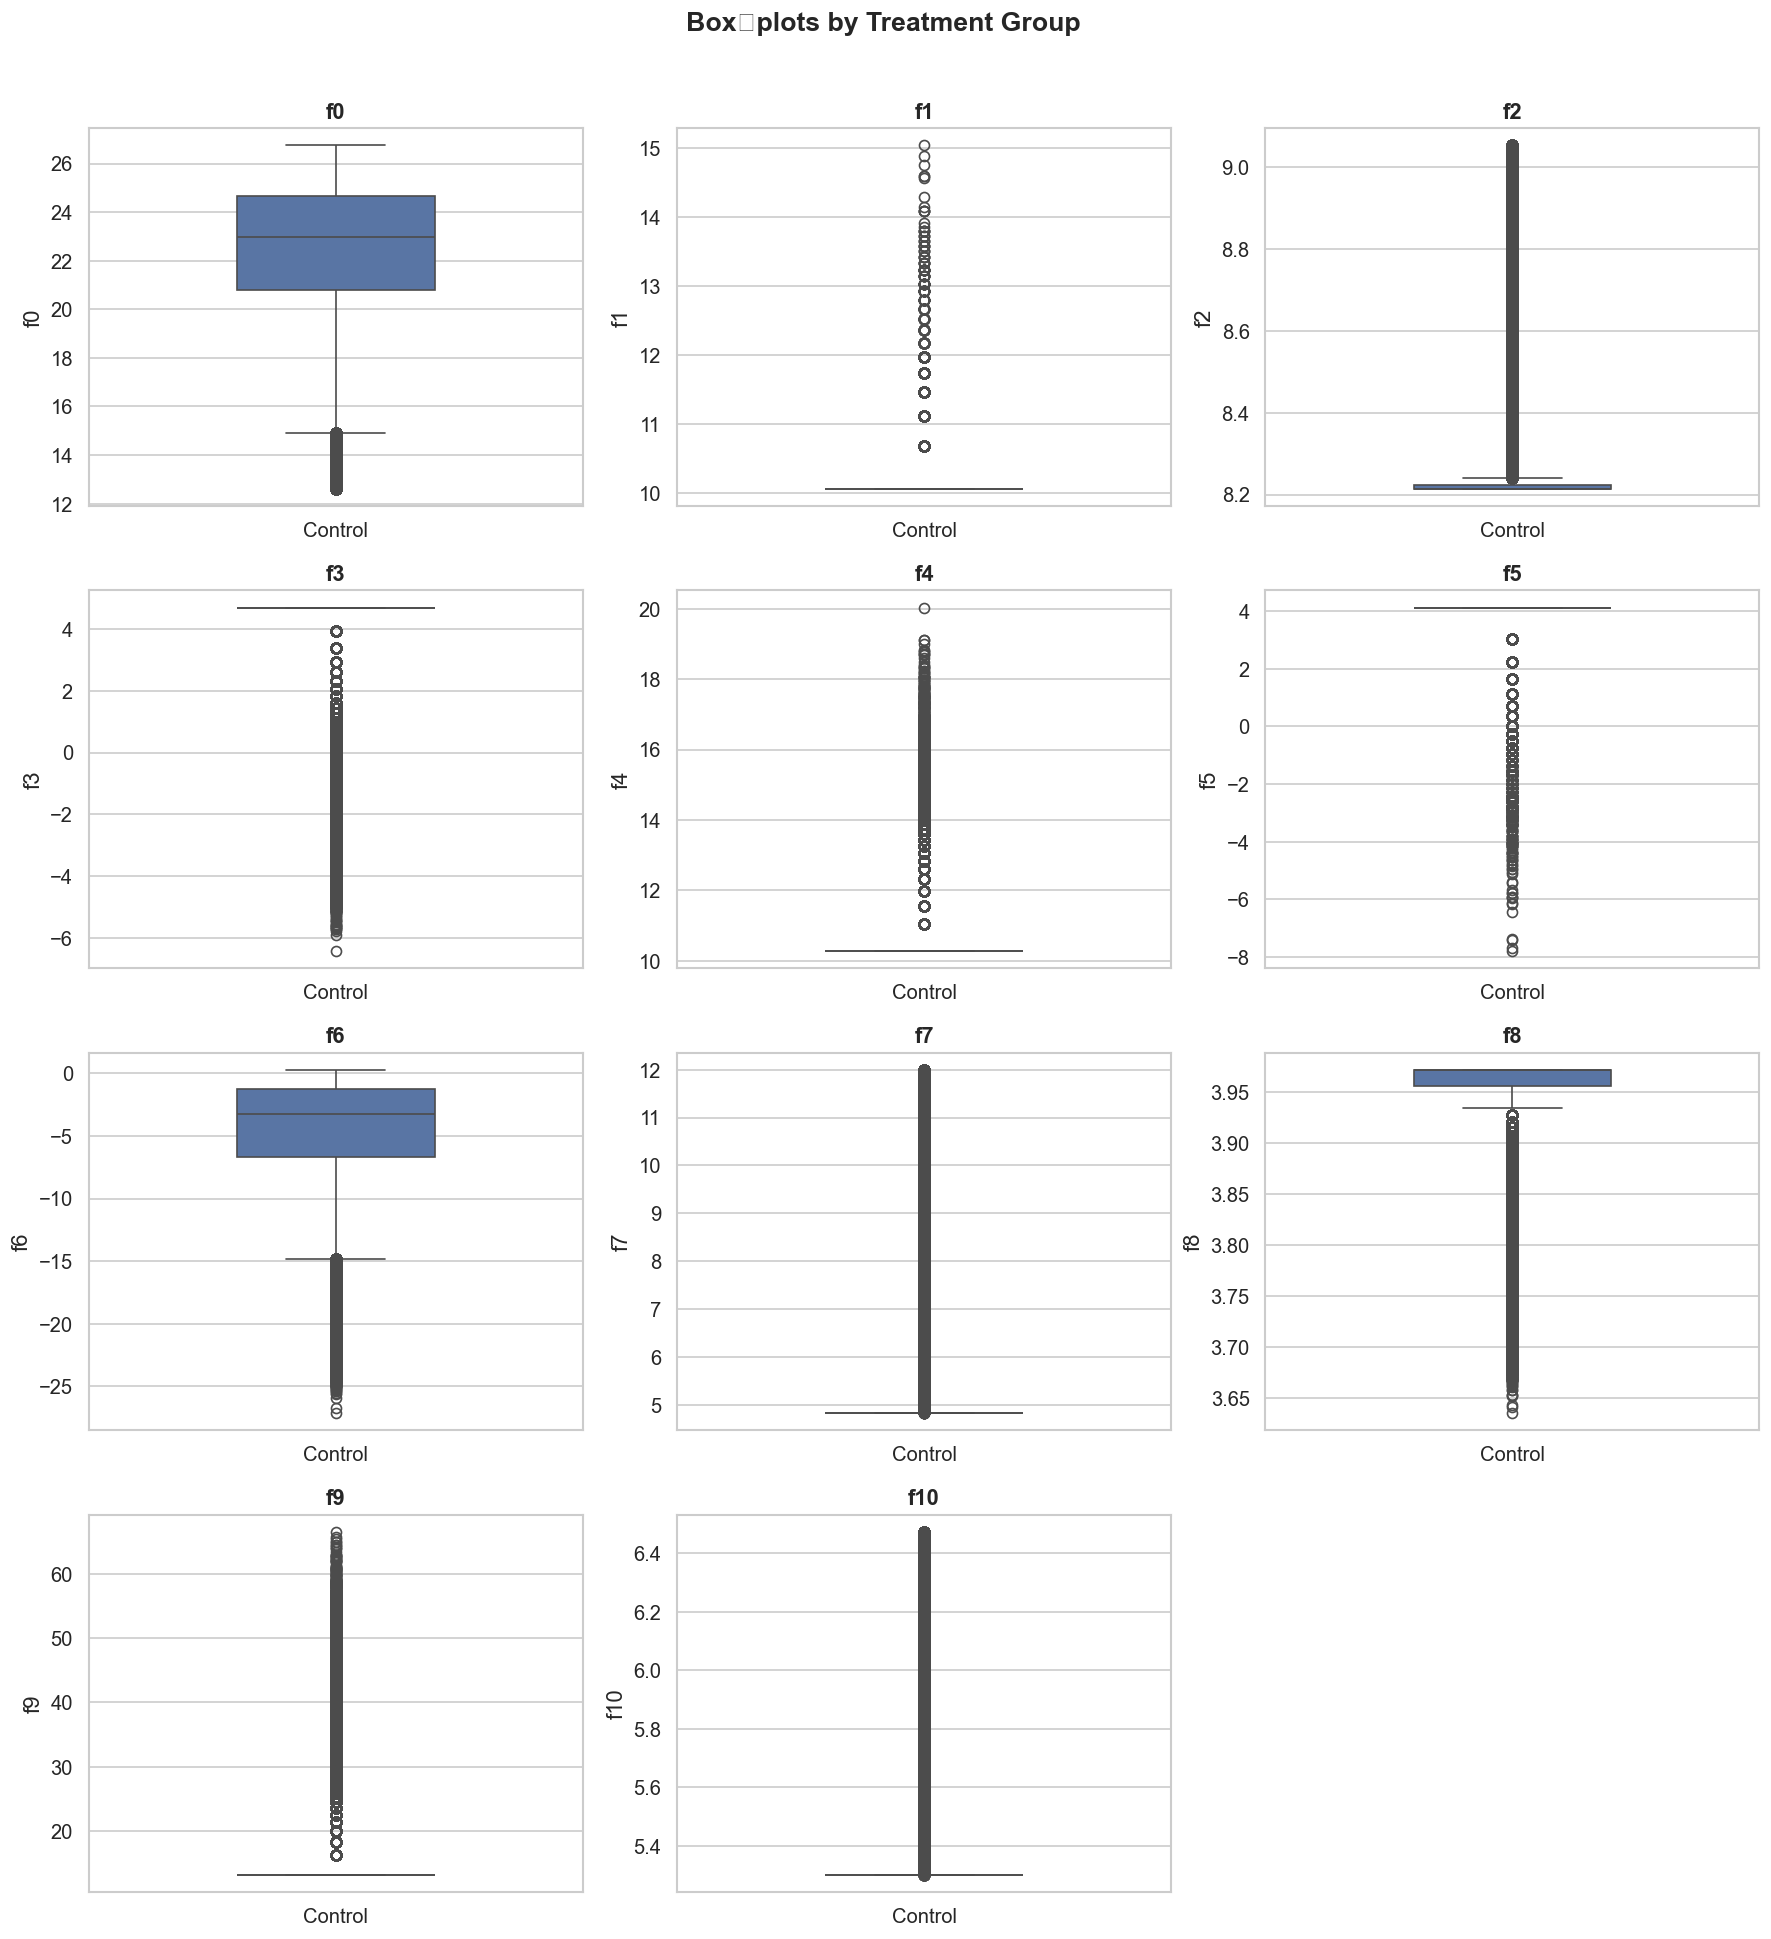

In [16]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    sns.boxplot(data=df, x=TREATMENT_COL, y=feat, ax=ax,
                palette=["#4C72B0", "#DD8452"], width=0.4)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(["Control", "Treatment"])

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Box‑plots by Treatment Group", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 12 · Tổng kết

### 12.1 Tổng quan dữ liệu

| Chỉ số | Giá trị | Nhận xét |
|---|---|---|
| Số dòng (train) | 700,000 | Đủ lớn cho modeling |
| Số cột | 13 | 11 features (f0–f10) + treatment + conversion |
| Kiểu dữ liệu | float64 (features), int64 (treatment, conversion) | Toàn bộ dạng số, không cần encoding |
| Missing values | **0** | Dữ liệu rất sạch, không cần xử lý missing |
| Duplicate rows | **13,750** (~1.96%) | Cần cân nhắc xử lý — có thể do bản chất dữ liệu (nhiều user có cùng feature pattern) |

### 12.2 Vấn đề nghiêm trọng: Treatment Distribution

> ⚠️ **CRITICAL**: Toàn bộ 700,000 dòng trong train set **chỉ chứa treatment=1** (100% treatment, 0% control).

**Nguyên nhân**: File CSV gốc (~14M dòng) được sắp xếp theo cột `treatment` (treatment=1 đứng trước treatment=0). Pipeline `make_dataset.py` mặc định chỉ đọc **1,000,000 dòng đầu tiên** (`--read-rows 1000000`), dẫn đến toàn bộ sample chỉ chứa nhóm treatment.

**Hậu quả**:
- ❌ Không thể tính **uplift** (cần cả treatment và control)
- ❌ Không thể so sánh conversion rate giữa 2 nhóm → Section 5 cho Δ = NaN
- ❌ Biểu đồ phân phối theo treatment group (Section 10) và box-plot (Section 11) không có ý nghĩa

**Giải pháp đề xuất**: Chạy lại `python -m src.data.make_dataset` với `--read-rows` đủ lớn (>= 5,000,000) hoặc **shuffle** dữ liệu trước khi sample, để đảm bảo cả 2 nhóm đều có mặt.

### 12.3 Target Imbalance (Class Imbalance)

| Target | Số lượng | Tỷ lệ |
|---|---|---|
| conversion = 0 | 696,671 | 99.52% |
| conversion = 1 | 3,329 | **0.48%** |

Target `conversion` cực kỳ **imbalanced** (tỷ lệ positive chỉ ~0.48%). Điều này ảnh hưởng lớn đến việc modeling:
- Cần sử dụng các metric phù hợp: **AUUC**, **Qini coefficient**, chứ không phải accuracy
- Có thể cần **stratified sampling** khi chia train/valid/test
- Các thuật toán uplift cần được calibrate cẩn thận do positive rate rất thấp

### 12.4 Phân tích Features

#### Thống kê mô tả
- Tất cả 11 features đều là **continuous** (float64)
- Nhiều features có **median = 25th = 75th percentile** (ví dụ: f1, f2, f3, f4, f5, f7, f8, f9, f10), cho thấy phân phối rất **tập trung** với phần lớn giá trị giống nhau (có thể là giá trị mặc định hoặc đã được xử lý)
- Chỉ **f0** và **f6** có sự phân tán rõ ràng giữa các quartile

#### Skewness (Độ lệch)

| Feature | Skewness | Đánh giá |
|---|---|---|
| f1 | **17.45** | Lệch phải cực mạnh |
| f5 | **-7.55** | Lệch trái rất mạnh |
| f4 | **7.49** | Lệch phải mạnh |
| f10 | **5.19** | Lệch phải mạnh |
| f9 | **4.65** | Lệch phải mạnh |
| f7 | **4.51** | Lệch phải mạnh |
| f3 | **-4.20** | Lệch trái mạnh |
| f8 | **-2.69** | Lệch trái |
| f2 | **1.70** | Lệch phải nhẹ |
| f6 | **-1.15** | Lệch trái nhẹ |
| f0 | **-1.03** | Gần symmetric |

**Nhận xét**: Hầu hết features có |skewness| > 1, nhiều feature có skew cực cao (f1 = 17.45). Điều này cho thấy:
- Phân phối rất **không chuẩn** (non-Gaussian)
- Có thể cần **log transform** hoặc **power transform** trước khi đưa vào model
- Tuy nhiên, các model tree-based (XGBoost, LightGBM) thường xử lý tốt dữ liệu skewed nên có thể không cần transform

### 12.5 Correlation Analysis

#### Top Correlation Pairs (giữa features)

| Feature 1 | Feature 2 | Correlation | Mức độ |
|---|---|---|---|
| f5 | f7 | **-0.754** | Tương quan nghịch mạnh |
| f8 | f9 | **-0.718** | Tương quan nghịch mạnh |
| f4 | f8 | **-0.658** | Tương quan nghịch đáng kể |
| f4 | f10 | **0.646** | Tương quan thuận đáng kể |
| f4 | f9 | **0.611** | Tương quan thuận đáng kể |

**Nhận xét**: Một số cặp features có **multicollinearity** khá cao (|r| > 0.6). Đối với linear models, cần cân nhắc loại bỏ bớt hoặc dùng PCA. Với tree-based models, multicollinearity ít ảnh hưởng hơn.

#### Correlation với Target (conversion)

| Feature | Correlation | Nhận xét |
|---|---|---|
| f4 | **0.354** | Tương quan thuận cao nhất |
| f9 | **0.324** | Tương quan thuận cao |
| f8 | **-0.248** | Tương quan nghịch |
| f3 | **-0.174** | Tương quan nghịch nhẹ |
| f1 | **0.135** | Tương quan thuận nhẹ |
| f2 | **0.005** | Gần như không tương quan |

**Nhận xét**: Tất cả correlations với target đều khá thấp (|r| < 0.4), điều này phổ biến trong bài toán uplift modeling. Features **f4** và **f9** có khả năng đóng vai trò quan trọng nhất trong việc dự đoán conversion.

### 12.6 Tóm tắt & Khuyến nghị

| # | Vấn đề | Mức độ | Hành động |
|---|---|---|---|
| 1 | **Thiếu control group** | 🔴 Critical | Rebuild dataset với đầy đủ cả treatment & control (shuffle trước khi sample hoặc tăng `--read-rows`) |
| 2 | **Target imbalance** (~0.48%) | 🟡 Medium | Sử dụng metric phù hợp (AUUC, Qini); stratified split |
| 3 | **Features rất skewed** | 🟡 Medium | Cân nhắc transform nếu dùng linear model; tree-based model xử lý tốt |
| 4 | **Multicollinearity** (f5-f7, f8-f9) | 🟢 Low | Ít ảnh hưởng với tree-based models |
| 5 | **Duplicate rows** (~2%) | 🟢 Low | Kiểm tra xem có cần remove hay do bản chất dữ liệu |
| 6 | **Missing values** | ✅ None | Dữ liệu sạch, không cần xử lý |
